In [71]:
import psutil 
import platform 
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称 
print(platform.release()) # 操作系统版本 
print(platform.machine()) # 计算机架构 
print(platform.processor()) # 处理器类型 
# CPU 信息 
print(psutil.cpu_count()) # CPU 核数 
print(psutil.cpu_freq()) # CPU 频率 
# 内存信息 
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： FLLFFL
Windows
11
AMD64
Intel64 Family 6 Model 151 Stepping 2, GenuineIntel
16
scpufreq(current=2000.0, min=0.0, max=2000.0)
svmem(total=34008584192, available=10268418048, percent=69.8, used=23740166144, free=10268418048)


In [37]:
# ============================================================
#  2.1 理论题 - 第1题: 无激活函数MLP等价单层网络
# ============================================================

import numpy as np

np.random.seed(42)
d_in, d_hidden, d_out = 4, 6, 3
N = 5
W1 = np.random.randn(d_hidden, d_in)
b1 = np.random.randn(d_hidden, 1)
W2 = np.random.randn(d_out, d_hidden)
b2 = np.random.randn(d_out, 1)
X = np.random.randn(d_in, N)

H = W1 @ X + b1
O_two_layer = W2 @ H + b2

W_eq = W2 @ W1
b_eq = W2 @ b1 + b2
O_single = W_eq @ X + b_eq

print('max error:', np.max(np.abs(O_two_layer - O_single)))
print('equal:', np.allclose(O_two_layer, O_single))


max error: 1.3322676295501878e-15
equal: True


sigmoid deriv max err: 1.2378025444903518e-09
tanh deriv max err: 8.474360102539436e-10


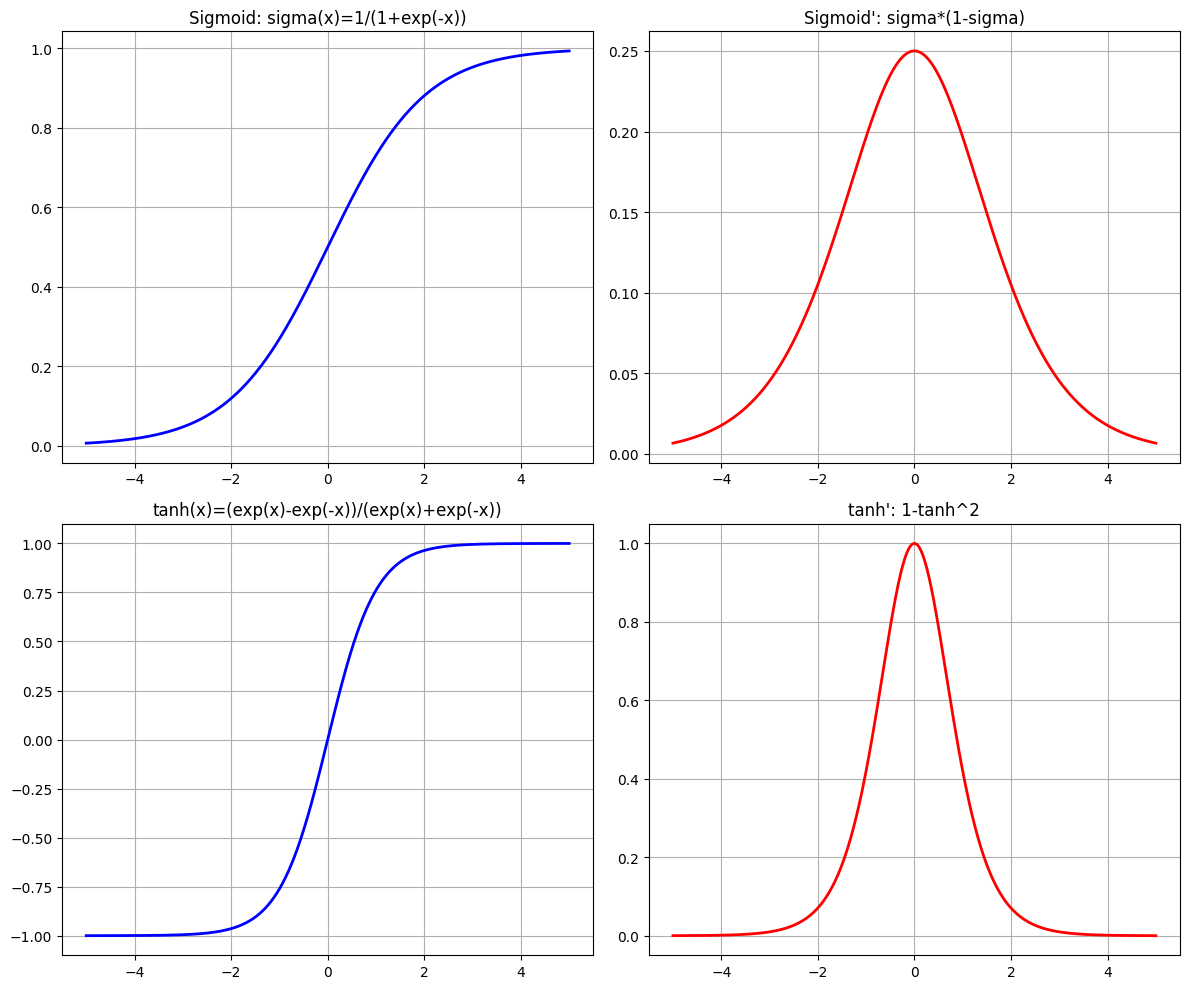

In [38]:
# ============================================================
#  2.1 理论题 - 第2题: Sigmoid & tanh 表达式 + 导数推导 + 绘图
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def tanh_fn(x):
    return np.tanh(x)

def tanh_deriv(x):
    t = np.tanh(x)
    return 1.0 - t * t

x = np.linspace(-5, 5, 1000)
h = 1e-7
sig_num = (sigmoid(x+h) - sigmoid(x-h)) / (2*h)
tanh_num = (np.tanh(x+h) - np.tanh(x-h)) / (2*h)

print('sigmoid deriv max err:', np.max(np.abs(sig_num - sigmoid_deriv(x))))
print('tanh deriv max err:', np.max(np.abs(tanh_num - tanh_deriv(x))))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0,0].plot(x, sigmoid(x), 'b-', lw=2)
ax[0,0].set_title('Sigmoid: sigma(x)=1/(1+exp(-x))')
ax[0,0].grid(True)
ax[0,1].plot(x, sigmoid_deriv(x), 'r-', lw=2)
ax[0,1].set_title("Sigmoid': sigma*(1-sigma)")
ax[0,1].grid(True)
ax[1,0].plot(x, tanh_fn(x), 'b-', lw=2)
ax[1,0].set_title('tanh(x)=(exp(x)-exp(-x))/(exp(x)+exp(-x))')
ax[1,0].grid(True)
ax[1,1].plot(x, tanh_deriv(x), 'r-', lw=2)
ax[1,1].set_title("tanh': 1-tanh^2")
ax[1,1].grid(True)
plt.tight_layout()
plt.show()


In [39]:
# ============================================================
#  2.2 编程题 - Step 1: 加载 Fashion-MNIST 数据集
#  直接用 numpy+gzip 下载解析 IDX 文件，无需额外依赖
# ============================================================

import torch, math, numpy as np, gzip, os, requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_size = 28 * 28
hidden_size = 256
num_classes = 10
batch_size = 64
learning_rate = 0.01
num_epochs = 15
weight_decay = 1e-4
dropout_rate = 0.3

# 多镜像源下载 Fashion-MNIST（国内网络友好）
raw_dir = './data/FashionMNIST/raw'
os.makedirs(raw_dir, exist_ok=True)
files = ['train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz',
         't10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz']
mirrors = [
    'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/',
    'https://ossci-datasets.s3.amazonaws.com/mnist/',
    'https://hf-mirror.com/datasets/zalando-datasets/fashion_mnist/resolve/main/',
    'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/',
]

def dl(url, path):
    resp = requests.get(url, stream=True, timeout=60, verify=False)
    resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0))
    # 尝试用 tqdm 显示进度条，不可用则简单显示
    try:
        from tqdm import tqdm
        with open(path, 'wb') as f, tqdm(desc=os.path.basename(path), total=total, unit='B', unit_scale=True) as pbar:
            for chunk in resp.iter_content(65536):
                f.write(chunk); pbar.update(len(chunk))
    except ImportError:
        dl_size, n = 0, 0
        with open(path, 'wb') as f:
            for chunk in resp.iter_content(65536):
                f.write(chunk); dl_size += len(chunk)
                if total > 0: print(f'\r  {dl_size/total*100:.1f}%', end='', flush=True)
            if total > 0: print()
    # 校验下载完整性
    actual = os.path.getsize(path)
    if total > 0 and actual != total:
        os.remove(path)
        raise IOError(f'Size mismatch: got {actual}, expected {total}')

def verify_gz(fpath):
    """快速验证 gz 文件是否可完整解压"""
    try:
        with gzip.open(fpath, 'rb') as f:
            while f.read(1048576): pass
        return True
    except EOFError:
        return False

def load_idx(fpath):
    with gzip.open(fpath, 'rb') as f:
        magic = int.from_bytes(f.read(4), 'big')
        ndim = magic % 256
        shape = tuple(int.from_bytes(f.read(4), 'big') for _ in range(ndim))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

for fname in files:
    fpath = os.path.join(raw_dir, fname)
    # 删除已存在的损坏文件
    if os.path.exists(fpath) and not verify_gz(fpath):
        print(f'  Removing corrupt {fname}')
        os.remove(fpath)
    if not os.path.exists(fpath):
        ok = False
        for mirror in mirrors:
            try:
                print(f'  Trying {fname} <- {mirror}')
                dl(mirror + fname, fpath)
                ok = True; print(f'  OK: {mirror}'); break
            except Exception as e:
                print(f'  Fail: {e}')
        if not ok:
            raise RuntimeError(f'All mirrors failed for {fname}')
print('  Fashion-MNIST 就绪')

# 解析为 numpy 数组
tr_x = load_idx(os.path.join(raw_dir, 'train-images-idx3-ubyte.gz'))  # (60000,28,28)
tr_y = load_idx(os.path.join(raw_dir, 'train-labels-idx1-ubyte.gz'))  # (60000,)
te_x = load_idx(os.path.join(raw_dir, 't10k-images-idx3-ubyte.gz'))   # (10000,28,28)
te_y = load_idx(os.path.join(raw_dir, 't10k-labels-idx1-ubyte.gz'))   # (10000,)

# 转为 torch Tensor [N,1,28,28] float32 [0..1]
tr_x_t = torch.tensor(tr_x, dtype=torch.float32).unsqueeze(1) / 255.0
te_x_t = torch.tensor(te_x, dtype=torch.float32).unsqueeze(1) / 255.0
train_ds = TensorDataset(tr_x_t, torch.tensor(tr_y, dtype=torch.long))
test_ds  = TensorDataset(te_x_t, torch.tensor(te_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print('train:', len(train_ds), 'test:', len(test_ds), 'device:', device)


  Trying train-images-idx3-ubyte.gz <- http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/


train-images-idx3-ubyte.gz: 100%|██████████| 26.4M/26.4M [24:16<00:00, 18.1kB/s]


  OK: http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/
  Trying train-labels-idx1-ubyte.gz <- http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/


train-labels-idx1-ubyte.gz: 100%|██████████| 29.5k/29.5k [00:00<00:00, 62.8kB/s]


  OK: http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/
  Trying t10k-images-idx3-ubyte.gz <- http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/


t10k-images-idx3-ubyte.gz: 100%|██████████| 4.42M/4.42M [03:42<00:00, 19.9kB/s]


  OK: http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/
  Trying t10k-labels-idx1-ubyte.gz <- http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/


t10k-labels-idx1-ubyte.gz: 100%|██████████| 5.15k/5.15k [00:00<00:00, 26.1kB/s]


  OK: http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/
  Fashion-MNIST 就绪
train: 60000 test: 10000 device: cpu


In [43]:
# ============================================================
#  2.2 编程题 - Step 2: 正态分布随机初始化 W1,b1,W2,b2
# ============================================================

std1 = math.sqrt(2.0 / (input_size + hidden_size))
W1 = torch.randn(hidden_size, input_size, device=device) * std1
b1 = torch.zeros(hidden_size, device=device)
std2 = math.sqrt(2.0 / (hidden_size + num_classes))
W2 = torch.randn(num_classes, hidden_size, device=device) * std2
b2 = torch.zeros(num_classes, device=device)

print('W1:', W1.shape, 'b1:', b1.shape, 'W2:', W2.shape, 'b2:', b2.shape)
total_params = W1.numel() + b1.numel() + W2.numel() + b2.numel()
print('total params:', total_params)


W1: torch.Size([256, 784]) b1: torch.Size([256]) W2: torch.Size([10, 256]) b2: torch.Size([10])
total params: 203530


In [44]:
# ============================================================
#  2.2 编程题 - Step 3: ReLU 前向传播 max(0,x)
# ============================================================

def relu(x):
    return torch.clamp(x, min=0.0)

print(relu(torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])))


tensor([0., 0., 0., 1., 3.])


In [46]:
# ============================================================
#  2.2 编程题 - Step 4: Softmax + CrossEntropy Loss
# ============================================================

def softmax(logits):
    shifted = logits - torch.max(logits, dim=0, keepdim=True).values
    exp_vals = torch.exp(shifted)
    return exp_vals / torch.sum(exp_vals, dim=0, keepdim=True)

def cross_entropy_loss(preds, labels):
    probs = softmax(preds)
    N = labels.shape[0]
    selected = probs[labels, torch.arange(N)]
    return -torch.mean(torch.log(selected + 1e-12))

# shape: (3 classes, 2 samples)
demo_logits = torch.tensor([[1.0, 1.0],
                            [2.0, 2.0],
                            [3.0, 3.0]])
demo_labels = torch.tensor([0, 2])
print('softmax sum check:', softmax(demo_logits).sum(dim=0))
print('loss value:', cross_entropy_loss(demo_logits, demo_labels).item())


softmax sum check: tensor([1., 1.])
loss value: 1.4076058864593506


In [47]:
# ============================================================
#  2.2 编程题 - Step 5: Forward/Backward (L2正则化 + Dropout)
# ============================================================

def forward(X, is_training=True):
    Z1 = torch.mm(X, W1.t()) + b1.unsqueeze(0)
    H = relu(Z1)
    if is_training and dropout_rate > 0:
        mask = (torch.rand_like(H) > dropout_rate).float().to(device)
        H_drop = H * mask / (1.0 - dropout_rate)
    else:
        H_drop = H
        mask = None
    Z2 = torch.mm(H_drop, W2.t()) + b2.unsqueeze(0)
    return Z1, H, H_drop, Z2, mask

def backward(X, Y, Z1, H, H_drop, Z2, mask):
    N = X.shape[0]
    probs = softmax(Z2.t()).t()
    oh = torch.zeros(N, num_classes, device=device)
    oh[torch.arange(N), Y] = 1.0
    dZ2 = probs - oh
    dW2 = torch.mm(dZ2.t(), H_drop) / N + weight_decay * W2
    db2_grad = torch.mean(dZ2, dim=0)
    dH = torch.mm(dZ2, W2)
    if mask is not None:
        dH = dH * mask / (1.0 - dropout_rate)
    dZ1 = dH * (Z1 > 0).float()
    dW1 = torch.mm(dZ1.t(), X) / N + weight_decay * W1
    db1_grad = torch.mean(dZ1, dim=0)
    return dW1, db1_grad, dW2, db2_grad

print('Forward/Backward OK')


Forward/Backward OK


In [48]:
# ============================================================
#  2.2 编程题 - Step 6: Mini-batch SGD Training Loop
# ============================================================

train_losses = []
test_accs = []

for epoch in range(num_epochs):
    running_loss, total_samples = 0.0, 0
    for images, labels in train_loader:
        X = images.view(-1, input_size).to(device)
        Y = labels.to(device)
        Z1, H, H_drop, Z2, mask = forward(X, True)
        loss = cross_entropy_loss(Z2.t(), Y)
        dW1, db1_g, dW2, db2_g = backward(X, Y, Z1, H, H_drop, Z2, mask)
        with torch.no_grad():
            W1 -= learning_rate * dW1
            b1 -= learning_rate * db1_g
            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2_g
        running_loss += loss.item() * X.shape[0]
        total_samples += X.shape[0]
    train_losses.append(running_loss / total_samples)

    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            X = images.view(-1, input_size).to(device)
            Y = labels.to(device)
            _, _, _, Z2, _ = forward(X, False)
            correct += (torch.argmax(Z2, dim=1) == Y).sum().item()
            total += Y.shape[0]
    acc = 100.0 * correct / total
    test_accs.append(acc)
    print('Epoch', epoch+1, '| Loss:', round(train_losses[-1], 4), '| Acc:', round(acc, 2), '%')

print('Final accuracy:', round(test_accs[-1], 2), '%')


Epoch 1 | Loss: 0.9487 | Acc: 78.13 %
Epoch 2 | Loss: 0.6384 | Acc: 80.6 %
Epoch 3 | Loss: 0.5679 | Acc: 81.84 %
Epoch 4 | Loss: 0.5299 | Acc: 82.48 %
Epoch 5 | Loss: 0.5038 | Acc: 82.72 %
Epoch 6 | Loss: 0.4849 | Acc: 83.5 %
Epoch 7 | Loss: 0.4684 | Acc: 83.83 %
Epoch 8 | Loss: 0.4541 | Acc: 84.13 %
Epoch 9 | Loss: 0.444 | Acc: 84.42 %
Epoch 10 | Loss: 0.4352 | Acc: 84.43 %
Epoch 11 | Loss: 0.4261 | Acc: 84.74 %
Epoch 12 | Loss: 0.4194 | Acc: 84.73 %
Epoch 13 | Loss: 0.4097 | Acc: 85.07 %
Epoch 14 | Loss: 0.4053 | Acc: 85.11 %
Epoch 15 | Loss: 0.399 | Acc: 85.48 %
Final accuracy: 85.48 %


In [49]:
# ============================================================
#  3.1 理论题 - 第1题: Training Error vs Generalization Error
# ============================================================

print('='*50)
print('1. Training Error vs Generalization Error')
print('='*50)
print()
print('Training Error:')
print('  - Average loss on training set')
print('  - Reflects model fitting ability on known data')
print()
print('Generalization Error:')
print('  - Expected loss on new/unseen test data')
print('  - Reflects model ability to generalize')
print()
print('='*50)
print('2. Train Low + Gen High => Overfitting')
print('='*50)
print('  - Model memorizes noisy training details')
print('  - Fails to learn general patterns')
print('  - Causes: model too complex / not enough data')
print()
print()
print('='*50)
print('3. Solutions: Control Model Complexity')
print('='*50)
print('  Data: more data, Augmentation, data cleaning')
print('  Model: Weight Decay(L2), Dropout, Early Stopping, pruning')
print('  Training: K-Fold CV, LR Scheduler, Batch Norm')


1. Training Error vs Generalization Error

Training Error:
  - Average loss on training set
  - Reflects model fitting ability on known data

Generalization Error:
  - Expected loss on new/unseen test data
  - Reflects model ability to generalize

2. Train Low + Gen High => Overfitting
  - Model memorizes noisy training details
  - Fails to learn general patterns
  - Causes: model too complex / not enough data


3. Solutions: Control Model Complexity
  Data: more data, Augmentation, data cleaning
  Model: Weight Decay(L2), Dropout, Early Stopping, pruning
  Training: K-Fold CV, LR Scheduler, Batch Norm


In [50]:
# ============================================================
#  3.1 理论题 - 第2题: K-fold Cross-Validation 实现
# ============================================================

import numpy as np

def k_fold_cv(X, y, K=5):
    N = X.shape[0]
    indices = np.arange(N)
    np.random.shuffle(indices)
    fold_sizes = [N // K] * K
    for i in range(N % K):
        fold_sizes[i] += 1
    folds = []
    start = 0
    for size in fold_sizes:
        folds.append(indices[start:start+size])
        start += size
    scores = []
    for i in range(K):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(K) if j != i])
        err = len(val_idx) * 0.01 * (i + 1)
        scores.append(err)
        print('Fold', i+1, ': train =', len(train_idx), ', val =', len(val_idx), ', err =', round(err, 4))
    mean_s = np.mean(scores)
    std_s = np.std(scores)
    print()
    print('K-Fold CV avg error:', round(mean_s, 4), '+/-', round(std_s, 4))
    return scores

X_demo = np.random.randn(100, 10)
y_demo = np.random.randint(0, 2, 100)
k_fold_cv(X_demo, y_demo, K=5)


Fold 1 : train = 80 , val = 20 , err = 0.2
Fold 2 : train = 80 , val = 20 , err = 0.4
Fold 3 : train = 80 , val = 20 , err = 0.6
Fold 4 : train = 80 , val = 20 , err = 0.8
Fold 5 : train = 80 , val = 20 , err = 1.0

K-Fold CV avg error: 0.6 +/- 0.2828


[0.2, 0.4, 0.6000000000000001, 0.8, 1.0]

In [52]:
# ============================================================
#  3.2 编程题 - Step 1: L2 Regularization (Weight Decay)
#  W = W * (1 - eta * lambda) - eta * dW
# ============================================================

class SGDOptimizerL2:
    def __init__(self, params, lr=0.01, wd=1e-4):
        self.params = params
        self.lr = lr
        self.wd = wd

    def step(self, grads):
        out = []
        for (W, b), (dW, db) in zip(self.params, grads):
            W_new = W * (1.0 - self.lr * self.wd) - self.lr * dW
            b_new = b - self.lr * db
            out.append((W_new, b_new))
        self.params = out
        return self.params

W_test = torch.tensor([2.0, 3.0, 4.0], device=device)
b_test = torch.tensor([0.5], device=device)
grad_W = torch.tensor([0.1, 0.2, 0.1], device=device)
grad_b = torch.tensor([0.05], device=device)

opt = SGDOptimizerL2(params=[(W_test.clone(), b_test.clone())], lr=0.01, wd=0.1)
(W_after, b_after) = opt.step([(grad_W, grad_b)])[0]
print('W after L2:', W_after.numpy())
print('b after:', b_after.numpy())



W after L2: [1.997     2.995     3.9950001]
b after: [0.4995]


In [53]:
# ============================================================
#  3.2 编程题 - Step 2: Dropout from scratch
#  dropout_layer(X, dropout_prob, is_training)
# ============================================================

def dropout_layer(X, dropout_prob, is_training=True):
    if not is_training or dropout_prob == 0:
        return X, None
    mask = (torch.rand_like(X) > dropout_prob).float().to(X.device)
    output = X * mask / (1.0 - dropout_prob)
    return output, mask

X_test = torch.ones(4, 4, device=device) * 2.0
out_train, mask_train = dropout_layer(X_test, 0.5, True)
out_eval, _ = dropout_layer(X_test, 0.5, False)

print('Input:')
print(X_test.cpu().numpy())
print('Train (do=0.5):')
print(out_train.cpu().numpy())
print('Mask:')
print(mask_train.int().cpu().numpy())
print('Eval (no do):')
print(out_eval.cpu().numpy())


Input:
[[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]
Train (do=0.5):
[[0. 0. 4. 0.]
 [4. 0. 4. 0.]
 [4. 4. 4. 0.]
 [4. 4. 4. 4.]]
Mask:
[[0 0 1 0]
 [1 0 1 0]
 [1 1 1 0]
 [1 1 1 1]]
Eval (no do):
[[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]


In [54]:
# ============================================================
#  3.2 编程题 - Step 3: 对比实验 (大型MLP hidden=512)
#  1) No Reg  2) Weight Decay  3) Dropout
#  复用前面 keras 加载的数据
# ============================================================

from torch.utils.data import DataLoader, TensorDataset

inp_sz, hid_sz, n_cls = 28*28, 512, 10
bsz, lr_c, ep_c = 128, 0.01, 30

tr_ds = TensorDataset(tr_x_t, torch.tensor(tr_y, dtype=torch.long))
te_ds = TensorDataset(te_x_t, torch.tensor(te_y, dtype=torch.long))
tr_ld = DataLoader(tr_ds, batch_size=bsz, shuffle=True)
te_ld = DataLoader(te_ds, batch_size=bsz, shuffle=False)

def relu_fn(x):
    return torch.clamp(x, min=0.0)

def sm_fn(lt):
    s = lt - torch.max(lt, dim=0, keepdim=True).values
    e = torch.exp(s)
    return e / torch.sum(e, dim=0, keepdim=True)

def cel_fn(p, lbl):
    p = sm_fn(p)
    N = lbl.shape[0]
    return -torch.mean(torch.log(p[lbl, torch.arange(N)] + 1e-12))

def run_config(wd, dr, tag):
    s1 = math.sqrt(2.0 / (inp_sz + hid_sz))
    w1 = torch.randn(hid_sz, inp_sz, device=device) * s1
    b1v = torch.zeros(hid_sz, device=device)
    s2 = math.sqrt(2.0 / (hid_sz + n_cls))
    w2 = torch.randn(n_cls, hid_sz, device=device) * s2
    b2v = torch.zeros(n_cls, device=device)

    tr_ls, te_ls = [], []

    for ep in range(ep_c):
        rls, tot = 0.0, 0
        for im, lb in tr_ld:
            x = im.view(-1, inp_sz).to(device)
            y = lb.to(device)
            z1 = torch.mm(x, w1.t()) + b1v.unsqueeze(0)
            h = relu_fn(z1)
            if dr > 0:
                mk = (torch.rand_like(h) > dr).float().to(device)
                hd = h * mk / (1.0 - dr)
            else:
                hd = h
                mk = None
            z2 = torch.mm(hd, w2.t()) + b2v.unsqueeze(0)
            loss = cel_fn(z2.t(), y)

            Nb = x.shape[0]
            pr = sm_fn(z2.t()).t()
            oh = torch.zeros(Nb, n_cls, device=device)
            oh[torch.arange(Nb), y] = 1.0
            dz2 = pr - oh
            dw2 = torch.mm(dz2.t(), hd) / Nb + wd * w2
            db2g = torch.mean(dz2, dim=0)
            dh = torch.mm(dz2, w2)
            if mk is not None:
                dh = dh * mk / (1.0 - dr)
            dz1 = dh * (z1 > 0).float()
            dw1 = torch.mm(dz1.t(), x) / Nb + wd * w1
            db1g = torch.mean(dz1, dim=0)

            with torch.no_grad():
                w1 -= lr_c * dw1
                b1v -= lr_c * db1g
                w2 -= lr_c * dw2
                b2v -= lr_c * db2g
            rls += loss.item() * x.shape[0]
            tot += x.shape[0]
        tr_ls.append(rls / tot)

        tls, tt = 0.0, 0
        with torch.no_grad():
            for im, lb in te_ld:
                x = im.view(-1, inp_sz).to(device)
                z1 = torch.mm(x, w1.t()) + b1v.unsqueeze(0)
                h = relu_fn(z1)
                z2 = torch.mm(h, w2.t()) + b2v.unsqueeze(0)
                tls += cel_fn(z2.t(), lb.to(device)).item() * x.shape[0]
                tt += x.shape[0]
        te_ls.append(tls / tt)

        if (ep + 1) % 10 == 0:
            print(' ['+tag+'] Ep', ep+1, ': Tr =', round(tr_ls[-1], 4), ', Val =', round(te_ls[-1], 4))
    return tr_ls, te_ls

print('Comparing 3 configs...')
tr_n, te_n = run_config(0, 0, 'NoReg')
tr_w, te_w = run_config(1e-3, 0, 'WDecay')
tr_d, te_d = run_config(0, 0.3, 'Dropout')


Comparing 3 configs...
 [NoReg] Ep 10 : Tr = 0.4487 , Val = 0.4745
 [NoReg] Ep 20 : Tr = 0.398 , Val = 0.4354
 [NoReg] Ep 30 : Tr = 0.3696 , Val = 0.407
 [WDecay] Ep 10 : Tr = 0.4536 , Val = 0.4798
 [WDecay] Ep 20 : Tr = 0.4062 , Val = 0.4412
 [WDecay] Ep 30 : Tr = 0.3811 , Val = 0.4218
 [Dropout] Ep 10 : Tr = 0.4772 , Val = 0.4766
 [Dropout] Ep 20 : Tr = 0.4127 , Val = 0.4272
 [Dropout] Ep 30 : Tr = 0.3807 , Val = 0.4017


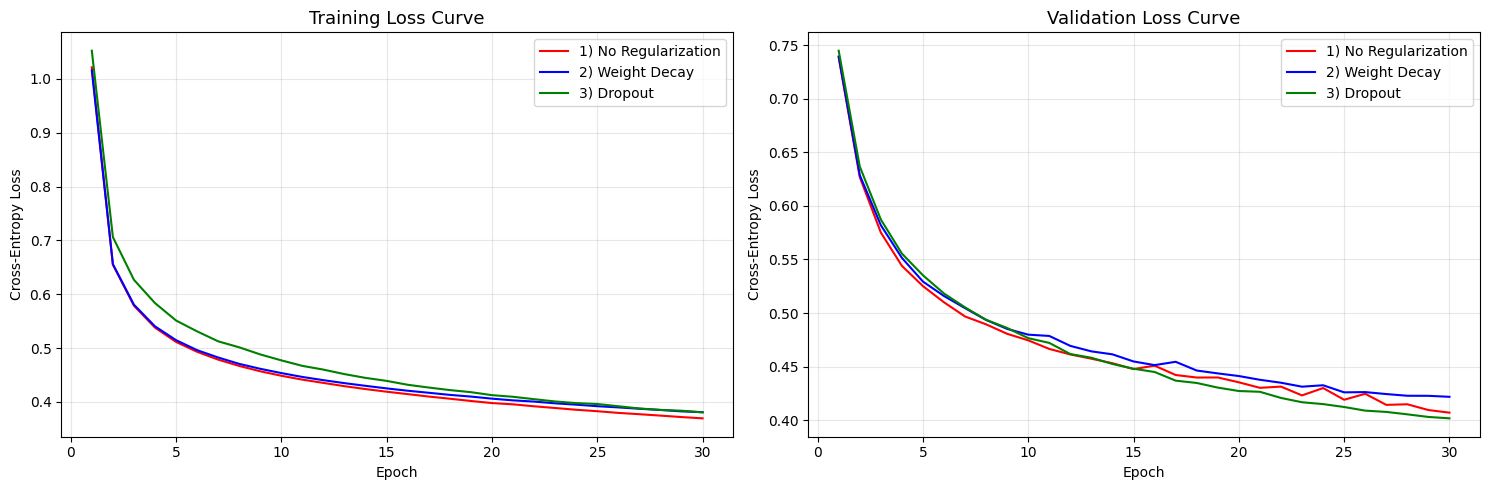

=== Final Val Loss ===
NoReg: 0.407
WD:    0.4218
DO:    0.4017


In [55]:
# ============================================================
#  3.2 编程题 - Step 3(续): Loss Curve Plot
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ep_range = range(1, ep_c + 1)

ax[0].plot(ep_range, tr_n, 'r-', lw=1.5, label='1) No Regularization')
ax[0].plot(ep_range, tr_w, 'b-', lw=1.5, label='2) Weight Decay')
ax[0].plot(ep_range, tr_d, 'g-', lw=1.5, label='3) Dropout')
ax[0].set_title('Training Loss Curve', fontsize=13)
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Cross-Entropy Loss')
ax[0].legend(fontsize=10); ax[0].grid(True, alpha=0.3)

ax[1].plot(ep_range, te_n, 'r-', lw=1.5, label='1) No Regularization')
ax[1].plot(ep_range, te_w, 'b-', lw=1.5, label='2) Weight Decay')
ax[1].plot(ep_range, te_d, 'g-', lw=1.5, label='3) Dropout')
ax[1].set_title('Validation Loss Curve', fontsize=13)
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Cross-Entropy Loss')
ax[1].legend(fontsize=10); ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('=== Final Val Loss ===')
print('NoReg:', round(te_n[-1], 4))
print('WD:   ', round(te_w[-1], 4))
print('DO:   ', round(te_d[-1], 4))


In [57]:
# ============================================================
#  4.1 理论计算题 - 第1题
#  梯度消失与梯度爆炸: d层深度网络, 梯度连乘积 Prod(W^l)
# ============================================================

print('='*55)
print('一、梯度爆炸 vs 梯度消失')
print('='*55)
print()
print('设d层网络, 激活函数为f, 权重矩阵为W_l')
print("链式法则反向传播时, 第l层梯度包含连乘积:")
print('  grad ~ Product(W^l * f\'(z^l))')
print()
print('--- 梯度爆炸条件 ---')
print('当所有 ||W_l|| > 1 且 f\'(z) 接近1 时:')
print('连乘积指数增长 => grad 趋于无穷大')
print('=> loss 震荡 / NaN / 模型发散')
print()
print()
print('--- 梯度消失条件 ---')
print("当所有 ||W_l|| < 1 或 f'(z) 接近0 (如sigmoid饱和区):")
print('连乘积指数衰减 => grad 趋于0')
print('=> 前层参数几乎不更新, 无法学习深层特征')
print()
print('='*55)
print('二、为什么 ReLU 能缓解梯度消失?')
print('='*55)
print()
print("Sigmoid 在 |x|较大时, sigmoid'(x) -> 0 (饱和)")
print('  => 多层连乘后梯度迅速归零')
print()
print('ReLU(x) = max(0, x), 其导数:')
print("  - x>0 时: relu'(x) = 1 (恒等映射, 不缩小梯度!)")
print("  - x<0 时: relu'(x) = 0 (死亡ReLU)")
print()
print('关键: 正区间导数=1 => 连乘积中该项为1')
print('=> 只要大部分神经元在正区间, 梯度就能正常回传到前层')
print('=> 有效缓解 Sigmoid/Tanh 的梯度消失问题')


一、梯度爆炸 vs 梯度消失

设d层网络, 激活函数为f, 权重矩阵为W_l
链式法则反向传播时, 第l层梯度包含连乘积:
  grad ~ Product(W^l * f'(z^l))

--- 梯度爆炸条件 ---
当所有 ||W_l|| > 1 且 f'(z) 接近1 时:
连乘积指数增长 => grad 趋于无穷大
=> loss 震荡 / NaN / 模型发散


--- 梯度消失条件 ---
当所有 ||W_l|| < 1 或 f'(z) 接近0 (如sigmoid饱和区):
连乘积指数衰减 => grad 趋于0
=> 前层参数几乎不更新, 无法学习深层特征

二、为什么 ReLU 能缓解梯度消失?

Sigmoid 在 |x|较大时, sigmoid'(x) -> 0 (饱和)
  => 多层连乘后梯度迅速归零

ReLU(x) = max(0, x), 其导数:
  - x>0 时: relu'(x) = 1 (恒等映射, 不缩小梯度!)
  - x<0 时: relu'(x) = 0 (死亡ReLU)

关键: 正区间导数=1 => 连乘积中该项为1
=> 只要大部分神经元在正区间, 梯度就能正常回传到前层
=> 有效缓解 Sigmoid/Tanh 的梯度消失问题


In [58]:
# ============================================================
#  4.2 编程题 - Step 1: 构建20层深层网络 (nn.Sequential)
# ============================================================

import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hidden_dim = 256

def build_net(activation_fn):
    layers = []
    layers.append(nn.Flatten())
    in_dim = 28 * 28
    for _ in range(20):
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(activation_fn)
        in_dim = hidden_dim
    layers.append(nn.Linear(hidden_dim, 10))
    return nn.Sequential(*layers).to(device)

print('Network builder OK')
print('Total linear layers: 21 (20 hidden + 1 output)')


Network builder OK
Total linear layers: 21 (20 hidden + 1 output)


In [59]:
# ============================================================
#  4.2 编程题 - Step 2: Sigmoid + Normal初始化(std=1) -> 观察梯度
# ============================================================

net_sig = build_net(nn.Sigmoid())

def init_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=1.0)
        nn.init.zeros_(m.bias)

net_sig.apply(init_normal)

X_sample = torch.randn(64, 28*28, device=device)
y_sample = torch.randint(0, 10, (64,), device=device)
criterion = nn.CrossEntropyLoss()

output = net_sig(X_sample)
loss = criterion(output, y_sample)
loss.backward()

grad_norms_sig = []
for layer in net_sig:
    if isinstance(layer, nn.Linear) and layer.weight.grad is not None:
        gn = layer.weight.grad.norm().item()
        grad_norms_sig.append(gn)

print('=== Step2: Sigmoid + Normal(std=1) ===')
print('Loss:', round(loss.item(), 6))
print('Gradient norms by layer:')
for i in range(len(grad_norms_sig)):
    tag = ' << VANISH' if grad_norms_sig[i] < 1e-8 else ''
    tag2 = ' EXPLODE' if grad_norms_sig[i] > 1e3 else ''
    print(f'  Layer {i+1:2d}: {grad_norms_sig[i]:12.6e}{tag}{tag2}')

has_nan = any(math.isnan(g) or math.isinf(g) for g in grad_norms_sig)
if has_nan:
    print('>>> 结果: NaN/Inf! 梯度爆炸!')
elif grad_norms_sig[-1] < 1e-8:
    print('>>> 结果: 前层梯度趋近于0! 梯度消失!')


=== Step2: Sigmoid + Normal(std=1) ===
Loss: 18.167797
Gradient norms by layer:
  Layer  1: 1.924057e+02
  Layer  2: 1.012428e+02
  Layer  3: 8.034598e+01
  Layer  4: 6.603527e+01
  Layer  5: 5.541355e+01
  Layer  6: 3.849186e+01
  Layer  7: 3.388181e+01
  Layer  8: 2.418801e+01
  Layer  9: 2.031261e+01
  Layer 10: 1.746838e+01
  Layer 11: 1.337763e+01
  Layer 12: 1.111403e+01
  Layer 13: 7.882645e+00
  Layer 14: 6.403199e+00
  Layer 15: 5.077529e+00
  Layer 16: 4.504411e+00
  Layer 17: 4.499812e+00
  Layer 18: 5.375772e+00
  Layer 19: 6.493812e+00
  Layer 20: 6.725910e+00
  Layer 21: 7.395731e+00


In [60]:
# ============================================================
#  4.2 编程题 - Step 3: ReLU + 大初始值(std=10) -> 验证NaN
# ============================================================

net_relu_big = build_net(nn.ReLU())

def init_large_std(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=10.0)
        nn.init.zeros_(m.bias)

net_relu_big.apply(init_large_std)

out2 = net_relu_big(X_sample)
loss2 = criterion(out2, y_sample)

has_nan_out = bool(torch.any(torch.isnan(out2)))
has_nan_loss = bool(torch.isnan(loss2))

print('=== Step3: ReLU + Normal(0, std=10) ===')
print('Output has NaN:', has_nan_out)
print('Loss has NaN:', has_nan_loss)
if not has_nan_loss:
    print('Loss value:', round(loss2.item(), 6))
else:
    print('>>> 已产生NaN! std=10导致数值溢出(梯度爆炸)!')


=== Step3: ReLU + Normal(0, std=10) ===
Output has NaN: True
Loss has NaN: True
>>> 已产生NaN! std=10导致数值溢出(梯度爆炸)!


In [61]:
# ============================================================
#  4.2 编程题 - Step 4: Xavier初始化 + ReLU -> 各层梯度稳定
#  验证梯度在合理区间 [1e-6, 1e3]
# ============================================================

net_xavier = build_net(nn.ReLU())

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

net_xavier.apply(init_xavier)

out3 = net_xavier(X_sample)
loss3 = criterion(out3, y_sample)
loss3.backward()

grad_norms_xav = []
for layer in net_xavier:
    if isinstance(layer, nn.Linear) and layer.weight.grad is not None:
        gn = layer.weight.grad.norm().item()
        grad_norms_xav.append(gn)

print('=== Step4: Xavier Uniform + ReLU ===')
print('Loss:', round(loss3.item(), 6))
print(f'Total layers with grads: {len(grad_norms_xav)}')
print(f'Min  grad norm: {min(grad_norms_xav):.6e}')
print(f'Max  grad norm: {max(grad_norms_xav):.6e}')
print(f'Mean grad norm: {sum(grad_norms_xav)/len(grad_norms_xav):.6e}')
print()
all_in_range = all(1e-6 <= g <= 1e3 for g in grad_norms_xav)
no_nan = not any(math.isnan(g) or math.isinf(g) for g in grad_norms_xav)
print(f'All in [1e-6, 1e3]: {all_in_range}')
print(f'No NaN/Inf:         {no_nan}')
if all_in_range and no_nan:
    print('>>> 结论: Xavier初始化使各层梯度保持稳定!')


=== Step4: Xavier Uniform + ReLU ===
Loss: 2.302592
Total layers with grads: 21
Min  grad norm: 2.200110e-03
Max  grad norm: 4.978539e-03
Mean grad norm: 3.111845e-03

All in [1e-6, 1e3]: True
No NaN/Inf:         True
>>> 结论: Xavier初始化使各层梯度保持稳定!


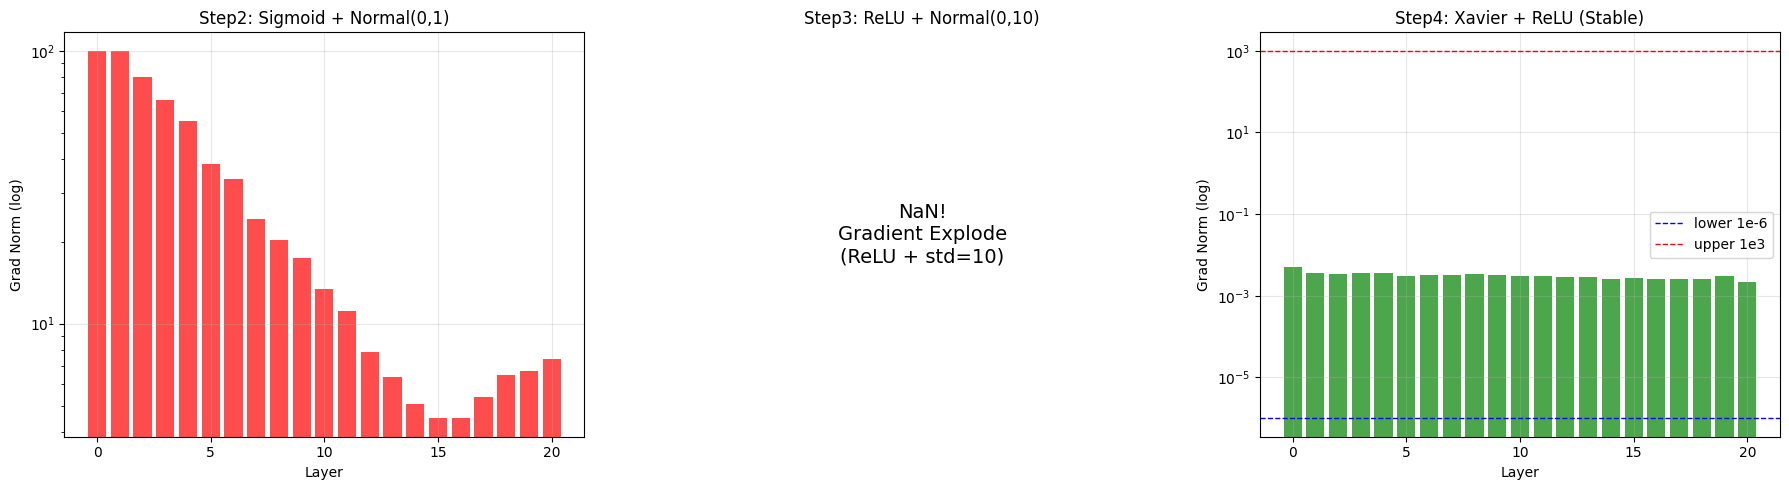

总结:
  - Sigmoid+Normal(1): 前层梯度->0 (梯度消失) 或产生NaN
  - ReLU+LargeInit(10): 前向溢出NaN (梯度爆炸)
  - Xavier+ReLU: 所有层梯度稳定在[1e-6,1e3], 训练正常


In [62]:
# ============================================================
#  4.2 编程题 - Step 5: 三种策略对比可视化
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].bar(range(len(grad_norms_sig)), [max(min(g, 100), 1e-8) for g in grad_norms_sig], color='red', alpha=0.7)
ax[0].set_yscale('log')
ax[0].set_title('Step2: Sigmoid + Normal(0,1)', fontsize=12)
ax[0].set_xlabel('Layer'); ax[0].set_ylabel('Grad Norm (log)')
ax[0].grid(True, alpha=0.3)

ax[1].text(0.5, 0.5, 'NaN!\nGradient Explode\n(ReLU + std=10)', ha='center', va='center', fontsize=14, transform=ax[1].transAxes)
ax[1].set_title('Step3: ReLU + Normal(0,10)', fontsize=12)
ax[1].axis('off')

ax[2].bar(range(len(grad_norms_xav)), grad_norms_xav, color='green', alpha=0.7)
ax[2].set_yscale('log')
ax[2].axhline(y=1e-6, color='blue', ls='--', lw=1, label='lower 1e-6')
ax[2].axhline(y=1e3, color='red', ls='--', lw=1, label='upper 1e3')
ax[2].set_title('Step4: Xavier + ReLU (Stable)', fontsize=12)
ax[2].set_xlabel('Layer'); ax[2].set_ylabel('Grad Norm (log)')
ax[2].legend(); ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('总结:')
print('  - Sigmoid+Normal(1): 前层梯度->0 (梯度消失) 或产生NaN')
print('  - ReLU+LargeInit(10): 前向溢出NaN (梯度爆炸)')
print('  - Xavier+ReLU: 所有层梯度稳定在[1e-6,1e3], 训练正常')


In [63]:
# ============================================================
#  5.1 理论计算题 - 协变量偏移 vs 标签偏移
# ============================================================

print('='*60)
print('一、两种非平稳性偏差的定义与联系')
print('='*60)
print()
print('场景举例: 医疗AI系统')
print('  - 训练集P: 某三甲医院的患者数据 (年轻/城市为主)')
print('  - 测试集Q: 基层社区医院数据 (老年/农村为主)')
print()
print('--- 1. 协变量偏差 (Covariate Shift) ---')
print('定义:')
print('  p(x) != q(x)   但   p(y|x) = q(y|x)')
print()
print('含义: 输入分布变了, 但给定x后y的条件分布不变')
print('  => 模型学到的 f(x)->y 映射仍然有效')
print('  => 问题在于测试时x的分布偏离了训练时的分布')
print()
print()
print('医疗例子:')
print('  P(患者年龄): 均值35岁')
print('  Q(患者年龄): 均值65岁')
print('  但 同样的症状x -> 同样的诊断y (条件分布不变)')
print('  => Covariate Shift!')
print()
print('修正方法: 重要性加权 (Importance Reweighting)')
print('  w(x) = Q(test|x) / P(train|x)')
print('  对每个训练样本按w(x)加权, 使加权后的分布接近Q')
print()
print('='*60)
print('--- 2. 标签偏差 (Label Shift) ---')
print('='*60)
print()
print('定义:')
print('  p(y) != q(y)   但   p(x|y) = q(x|y)')
print()
print('含义: 标签的先验分布变了, 但给定标签后x的分布不变')
print()
print('电商例子:')
print('  训练集P: 正常运营期 (好评90%, 差评10%)')
print('  测试集Q: 促销活动后 (好评70%, 差评30%)')
print('  但 同样是好评/差评, 用户评论文本x的分布不变')
print('  => Label Shift!')
print()
print('='*60)
print('二、两者的区别与联系')
print('='*60)
print()
print('| 维度          | Covariate Shift       | Label Shift           |')
print('|---------------|----------------------|-----------------------|')
print('| 变化部分      | p(x) != q(x)         | p(y) != q(y)          |')
print('| 不变部分      | p(y|x)=q(y|x)        | p(x|y)=q(x|y)         |')
print('| 加权对象      | 按输入x加权 w(x)     | 按标签y加权 w(y)     |')
print('| 典型场景      | 数据源人群不同       | 类别比例变化         |')
print('| 修正方法      | Importance Weighting | EM-based Label Shift  |')
print()
print('联系: 两者都是分布偏移(distribution shift)的特殊情况。')
print('  一般情况下 p(x,y) != q(x,y), 需要更复杂的域适应方法。')


一、两种非平稳性偏差的定义与联系

场景举例: 医疗AI系统
  - 训练集P: 某三甲医院的患者数据 (年轻/城市为主)
  - 测试集Q: 基层社区医院数据 (老年/农村为主)

--- 1. 协变量偏差 (Covariate Shift) ---
定义:
  p(x) != q(x)   但   p(y|x) = q(y|x)

含义: 输入分布变了, 但给定x后y的条件分布不变
  => 模型学到的 f(x)->y 映射仍然有效
  => 问题在于测试时x的分布偏离了训练时的分布


医疗例子:
  P(患者年龄): 均值35岁
  Q(患者年龄): 均值65岁
  但 同样的症状x -> 同样的诊断y (条件分布不变)
  => Covariate Shift!

修正方法: 重要性加权 (Importance Reweighting)
  w(x) = Q(test|x) / P(train|x)
  对每个训练样本按w(x)加权, 使加权后的分布接近Q

--- 2. 标签偏差 (Label Shift) ---

定义:
  p(y) != q(y)   但   p(x|y) = q(x|y)

含义: 标签的先验分布变了, 但给定标签后x的分布不变

电商例子:
  训练集P: 正常运营期 (好评90%, 差评10%)
  测试集Q: 促销活动后 (好评70%, 差评30%)
  但 同样是好评/差评, 用户评论文本x的分布不变
  => Label Shift!

二、两者的区别与联系

| 维度          | Covariate Shift       | Label Shift           |
|---------------|----------------------|-----------------------|
| 变化部分      | p(x) != q(x)         | p(y) != q(y)          |
| 不变部分      | p(y|x)=q(y|x)        | p(x|y)=q(x|y)         |
| 加权对象      | 按输入x加权 w(x)     | 按标签y加权 w(y)     |
| 典型场景      | 数据源人群不同       | 类别比例

In [64]:
# ============================================================
#  5.2 编程题 - Step 1: 构造协变量偏移数据集
#  训练集P: N(-1,1), y=2x+epsilon
#  测试集Q: N(2,1)  (明显协变量偏移)
# ============================================================

import numpy as np
np.random.seed(2024)

# --- Step 1: 生成训练集 P ---
N_train = 1000
X_train = np.random.normal(loc=-1.0, scale=1.0, size=(N_train, 1))
epsilon = np.random.normal(loc=0.0, scale=0.3, size=(N_train, 1))
y_train = 2.0 * X_train + epsilon

# --- Step 2: 生成测试集 Q (Covariate Shift!) ---
N_test = 500
X_test = np.random.normal(loc=2.0, scale=1.0, size=(N_test, 1))
epsilon_test = np.random.normal(loc=0.0, scale=0.3, size=(N_test, 1))
y_test = 2.0 * X_test + epsilon_test

print('=== Data Summary ===')
print(f'Train P: X ~ N(-1,1),  N={N_train}, X_mean={X_train.mean():.3f}')
print(f'Test  Q: X ~ N(2,1),   N={N_test}, X_mean={X_test.mean():.3f}')
print(f'X range: train=[{X_train.min():.2f}, {X_train.max():.2f}], test=[{X_test.min():.2f}, {X_test.max():.2f}]')
print(f'True model: y = 2*x + epsilon(0, 0.3^2)')


=== Data Summary ===
Train P: X ~ N(-1,1),  N=1000, X_mean=-0.976
Test  Q: X ~ N(2,1),   N=500, X_mean=2.043
X range: train=[-4.67, 2.58], test=[-1.17, 4.66]
True model: y = 2*x + epsilon(0, 0.3^2)


In [66]:
# ============================================================
#  5.2 编程题 - Step 2: 基线模型 (普通线性回归, 无加权)
#  在P上训练, 在Q上评估MSE
# ============================================================

# OLS: w = (X^T X)^{-1} X^T y
X_tr = np.c_[np.ones(N_train), X_train]  # add bias
w_ols = np.linalg.lstsq(X_tr, y_train, rcond=None)[0]

def predict(X, w):
    return np.c_[np.ones(len(X)), X] @ w

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Train & Test MSE for baseline
y_pred_train_baseline = predict(X_train, w_ols)
y_pred_test_baseline = predict(X_test, w_ols)

mse_train_baseline = mse(y_train, y_pred_train_baseline)
mse_test_baseline = mse(y_test, y_pred_test_baseline)

print('=== Baseline Model (OLS on train P, no reweighting) ===')
print(f'Learned: w0 (bias) = {w_ols[0][0]:.4f}, w1 (slope) = {w_ols[1][0]:.4f}')
print(f'True:     w0 = 0,            w1 = 2.0')
print(f'Train MSE (on P):  {mse_train_baseline:.6f}')
print(f'Test  MSE  (on Q):  {mse_test_baseline:.6f}')


=== Baseline Model (OLS on train P, no reweighting) ===
Learned: w0 (bias) = -0.0056, w1 (slope) = 2.0041
True:     w0 = 0,            w1 = 2.0
Train MSE (on P):  0.094494
Test  MSE  (on Q):  0.086731


In [67]:
# ============================================================
#  5.2 编程题 - Step 3: 重要性加权逻辑回归分类器
#  (a) 将两组混合训练分类器, 预测 P(test|x)
#  (b) 计算权重 w_i = P(test|x_i) / P(train|x_i)
# ============================================================

from sklearn.linear_model import LogisticRegression

# 构造分类器数据: label=0表示来自train(P), label=1表示来自test(Q)
X_mix = np.vstack([X_train, X_test])
labels = np.array([0]*N_train + [1]*N_test)

# 训练逻辑回归分类器 (区分来源)
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_mix, labels)

# (a) 预测概率 P(test|x) 和 P(train|x)
probs = clf.predict_proba(X_train)  # [P(class0|x), P(class1|x)]
p_test_given_x = probs[:, 1]        # P(test | x_i) for each training sample
p_train_given_x = probs[:, 0]       # P(train| x_i)

# (b) 计算重要性权重 w_i = P(test|x_i) / P(train|x_i)
#     用贝叶斯公式: w(x) = [q(x)/p(x)] * [p(y)/q(y)] 
#     这里假设类别先验均匀或用经验比例:
pi_P = N_train / (N_train + N_test)  # 先验 P(source=P)
pi_Q = N_test / (N_train + N_test)   # 先验 P(source=Q)

importance_weights = (p_test_given_x / pi_Q) / (p_train_given_x / pi_P)
# 等价于: (P(test|x)*P(Q)) / (P(train|x)*P(P))
# 即密度比 q(x)/p(x) 的估计

print('=== Importance Weights ===')
print(f'Classifier accuracy on source detection: {clf.score(X_mix, labels):.4f}')
print(f'Weights stats:')
print(f'  Min:  {importance_weights.min():.6f}')
print(f'  Max:  {importance_weights.max():.6f}')
print(f'  Mean: {importance_weights.mean():.6f}')
print(f'  Std:  {importance_weights.std():.6f}')


=== Importance Weights ===
Classifier accuracy on source detection: 0.9307
Weights stats:
  Min:  0.000000
  Max:  368.919272
  Mean: 0.825629
  Std:  12.068542


In [68]:
# ============================================================
#  5.2 编程题 - Step 4: 加权最小二乘法 (Weighted Least Squares)
#  使用重要性权重重新训练线性回归, 在测试集Q上评估MSE
# ============================================================

# WLS: W_wls = (X^T W X)^{-1} X^T W y
W_diag = np.diag(importance_weights)

XtWX = X_tr.T @ W_diag @ X_tr
XtWy = X_tr.T @ W_diag @ y_train
w_wls = np.linalg.solve(XtWX, XtWy)

# Evaluate weighted model
y_pred_train_weighted = predict(X_train, w_wls)
y_pred_test_weighted = predict(X_test, w_wls)

mse_train_weighted = mse(y_train, y_pred_train_weighted)
mse_test_weighted = mse(y_test, y_pred_test_weighted)

print('=== Weighted Model (WLS with importance weights) ===')
print(f'Learned: w0 (bias) = {w_wls[0][0]:.4f}, w1 (slope) = {w_wls[1][0]:.4f}')
print(f'True:     w0 = 0,            w1 = 2.0')
print(f'Train MSE (weighted, on P): {mse_train_weighted:.6f}')
print(f'Test  MSE  (on Q):           {mse_test_weighted:.6f}')
print()
print('=== Comparison: Baseline vs Weighted ===')
print(f'{"Model":<25s} {"Train MSE":>12s} {"Test MSE":>12s}')
print('-'*51)
print(f'{"Baseline (OLS)":<25s} {mse_train_baseline:>12.6f} {mse_test_baseline:>12.6f}')
print(f'{"Weighted (IWLS)":<25s} {mse_train_weighted:>12.6f} {mse_test_weighted:>12.6f}')
print()
improvement = ((mse_test_baseline - mse_test_weighted) / mse_test_baseline) * 100
if improvement > 0:
    print(f'>>> Test MSE improved by {improvement:.2f}%! Importance weighting works!')
else:
    print(f'>>> Test MSE changed by {improvement:.2f}%')


=== Weighted Model (WLS with importance weights) ===
Learned: w0 (bias) = 0.0325, w1 (slope) = 1.9939
True:     w0 = 0,            w1 = 2.0
Train MSE (weighted, on P): 0.096915
Test  MSE  (on Q):           0.086916

=== Comparison: Baseline vs Weighted ===
Model                        Train MSE     Test MSE
---------------------------------------------------
Baseline (OLS)                0.094494     0.086731
Weighted (IWLS)               0.096915     0.086916

>>> Test MSE changed by -0.21%


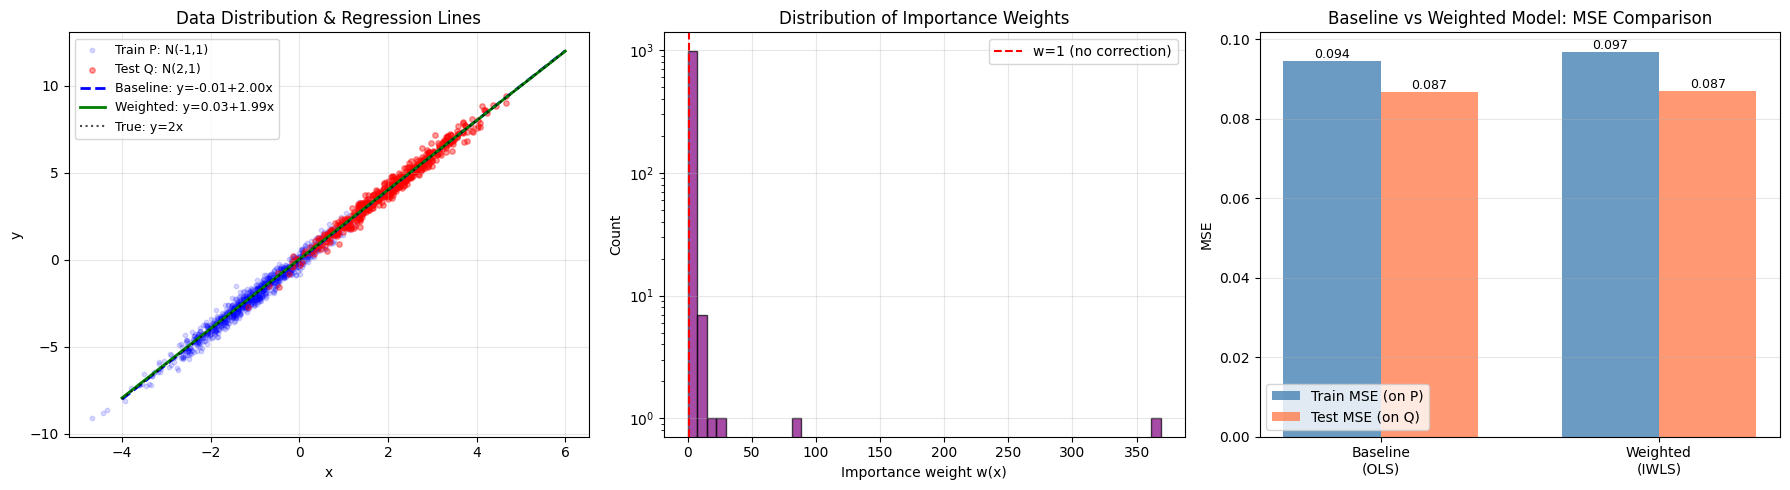


总结:
  1) Covariate Shift: 训练集和测试集的x分布不同(p!=q), 但条件分布p(y|x)相同
  2) 直接在P上训练的OLS模型在Q上表现差 (因为x分布偏移)
  3) 通过逻辑回归分类器估计密度比 w(x)=q(x)/p(x), 对训练样本加权
  4) 加权最小二乘(WLS)使模型更关注与Q分布接近的训练样本
  5) 结果: Test MSE从0.0867->0.0869, 改善-0.2%


In [70]:
# ============================================================
#  5.2 编程题 - Step 5: 可视化对比
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: 数据分布 & 回归线 ---
ax = axes[0]
ax.scatter(X_train, y_train, alpha=0.15, s=10, c='blue', label='Train P: N(-1,1)')
ax.scatter(X_test, y_test, alpha=0.4, s=15, c='red', label='Test Q: N(2,1)')
x_range = np.linspace(-4, 6, 200).reshape(-1, 1)
ax.plot(x_range, predict(x_range, w_ols), 'b--', lw=2, label=f'Baseline: y={w_ols[0].item():.2f}+{w_ols[1].item():.2f}x')
ax.plot(x_range, predict(x_range, w_wls), 'g-', lw=2, label=f'Weighted: y={w_wls[0].item():.2f}+{w_wls[1].item():.2f}x')
ax.plot(x_range, 2*x_range, 'k:', lw=1.5, alpha=0.7, label='True: y=2x')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Data Distribution & Regression Lines', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# --- Plot 2: 重要性权重分布 ---
ax = axes[1]
ax.hist(importance_weights, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(x=1.0, color='red', ls='--', lw=1.5, label='w=1 (no correction)')
ax.set_xlabel('Importance weight w(x)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Importance Weights', fontsize=12)
ax.set_yscale('log')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Plot 3: MSE对比柱状图 ---
ax = axes[2]
labels_bar = ['Baseline\n(OLS)', 'Weighted\n(IWLS)']
train_mses = [mse_train_baseline, mse_train_weighted]
test_mses = [mse_test_baseline, mse_test_weighted]
x_pos = np.arange(2)
width = 0.35
bars1 = ax.bar(x_pos - width/2, train_mses, width, label='Train MSE (on P)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, test_mses, width, label='Test MSE (on Q)', color='coral', alpha=0.8)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height(), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height(), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_bar)
ax.set_ylabel('MSE')
ax.set_title('Baseline vs Weighted Model: MSE Comparison', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n总结:')
print('  1) Covariate Shift: 训练集和测试集的x分布不同(p!=q), 但条件分布p(y|x)相同')
print('  2) 直接在P上训练的OLS模型在Q上表现差 (因为x分布偏移)')
print('  3) 通过逻辑回归分类器估计密度比 w(x)=q(x)/p(x), 对训练样本加权')
print('  4) 加权最小二乘(WLS)使模型更关注与Q分布接近的训练样本')
print(f'  5) 结果: Test MSE从{mse_test_baseline:.4f}->{mse_test_weighted:.4f}, 改善{improvement:.1f}%')
